## Framework based on Eguia et al. (2018, GEB) --- Motivating example

- Vertical contracting game with one supplier supplies two retailers. 

- The supplier provides a price either high or low: pL or pH.

- Each retailer knows only its price at which it buys inputs and then choose a quantity of input between 0, 1 , 2 or 3.

- The inverse demand is P(1) = 21, p(2) = 20, p(3) = 15, p(4) = 14, p(5) = 10, p(6) = 6.

- Contracts are interim unobservable (secret contracting).

Timing of the game:

- The supplier (Player U) chooses a pair of prices (p1, p2) to secretly offer to each retailer.

- Each retailer (Player 1 and Player 2) only knows their own price, and chooses a quantity from {0,1,2,3}.

In [14]:
import pandas as pd
import numpy as np
import itertools
import random
import matplotlib.pyplot as plt

In [30]:
prices = [7, 16]  # pL, pH
quantities = [0, 1, 2, 3]
inverse_demand = {1: 21, 2: 20, 3: 15, 4: 14, 5: 10, 6: 6}

def market_price(Q):
    return inverse_demand.get(Q, 0)

    
# Equilibrium L: (pL,pL), 2, 2  --> "Cournot" outcome
# Equilibrium H: (pH,pH), 1, 1  --> "Monopoly" outcome

In [8]:
def retailer_payoff_matrix(retailer_id):
    matrix = np.zeros((4, 8))
    other_id = 1 - retailer_id
    col_labels = []
    col_index = 0

    for q_opp in quantities:  
        for own_price in prices:  
            for i, q in enumerate(quantities):  
                q_profile = [0, 0]
                q_profile[retailer_id] = q
                q_profile[other_id] = q_opp
                Q = sum(q_profile)
                market_p = market_price(Q)
                profit = market_p * q - own_price * q
                matrix[i, col_index] = profit
            col_labels.append((q_opp, own_price))  
            col_index += 1

    return matrix, col_labels

In [31]:
# The possible actions combinations
price_profiles = list(itertools.product(prices, repeat=2)) 
quantity_profiles = list(itertools.product(quantities, repeat=2))  

def supplier_payoff_matrix():
    matrix = np.zeros((4, 16))
    row_labels = price_profiles
    col_labels = quantity_profiles

    for i, (p1, p2) in enumerate(price_profiles):
        for j, (q1, q2) in enumerate(quantity_profiles):
            revenue = p1 * q1 + p2 * q2
            matrix[i, j] = revenue
    
    return matrix, row_labels, col_labels


In [10]:
# Retailer 1's matrix
r1_matrix, r1_cols = retailer_payoff_matrix(retailer_id=0)

# Retailer 2's matrix
r2_matrix, r2_cols = retailer_payoff_matrix(retailer_id=1)

# Supplier's matrix
s_matrix, s_rows, s_cols = supplier_payoff_matrix()


In [34]:
def print_matrix(matrix, row_labels, col_labels, title="Matrix"):
    col_width = 12

    def format_label(label):
        if isinstance(label, tuple):
            return f"{label}".replace(" ", "")
        return str(label)

    print(f"\n{title}")
    print("=" * (col_width + col_width * len(col_labels)))

    # Print column headers
    header = " " * col_width
    for col in col_labels:
        header += format_label(col).ljust(col_width)
    print(header)

    # Print each row
    for i, row in enumerate(matrix):
        row_label = format_label(row_labels[i]).ljust(col_width)
        row_values = "".join(f"{val: .1f}".ljust(col_width) for val in row)
        print(row_label + row_values)

In [33]:
print_matrix(r1_matrix, quantities, r1_cols, title="Retailer 1 Payoff Matrix")
print_matrix(r2_matrix, quantities, r2_cols, title="Retailer 2 Payoff Matrix")
print_matrix(s_matrix, s_rows, s_cols, title="Supplier Payoff Matrix")


Retailer 1 Payoff Matrix
            (0,7)       (0,16)      (1,7)       (1,16)      (2,7)       (2,16)      (3,7)       (3,16)      
0            0.0         0.0         0.0         0.0         0.0         0.0         0.0         0.0        
1            14.0        5.0         13.0        4.0         8.0        -1.0         7.0        -2.0        
2            26.0        8.0         16.0       -2.0         14.0       -4.0         6.0        -12.0       
3            24.0       -3.0         21.0       -6.0         9.0        -18.0       -3.0        -30.0       

Retailer 2 Payoff Matrix
            (0,7)       (0,16)      (1,7)       (1,16)      (2,7)       (2,16)      (3,7)       (3,16)      
0            0.0         0.0         0.0         0.0         0.0         0.0         0.0         0.0        
1            14.0        5.0         13.0        4.0         8.0        -1.0         7.0        -2.0        
2            26.0        8.0         16.0       -2.0         14.0       -4.0

In [23]:
# Better view of payoff matrices

def as_dataframe(matrix, row_labels, col_labels):
    def format_label(label):
        if isinstance(label, tuple):
            return str(label).replace(" ", "")
        return str(label)
    
    formatted_rows = [format_label(lbl) for lbl in row_labels]
    formatted_cols = [format_label(lbl) for lbl in col_labels]

    df = pd.DataFrame(matrix, index=formatted_rows, columns=formatted_cols)
    return df

# Convert each matrix into a nice readable table
r1_df = as_dataframe(r1_matrix, quantities, r1_cols)
r2_df = as_dataframe(r2_matrix, quantities, r2_cols)
s_df = as_dataframe(s_matrix, s_rows, s_cols)

# Display the tables
print("Retailer 1's Payoff Matrix")
display(r1_df)

print("\nRetailer 2's Payoff Matrix")
display(r2_df)

print("\nSupplier's Payoff Matrix")
display(s_df)


Retailer 1's Payoff Matrix


,"(0,7)","(0,16)","(1,7)","(1,16)","(2,7)","(2,16)","(3,7)","(3,16)"
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,14.0,5.0,13.0,4.0,8.0,-1.0,7.0,-2.0
2,26.0,8.0,16.0,-2.0,14.0,-4.0,6.0,-12.0
3,24.0,-3.0,21.0,-6.0,9.0,-18.0,-3.0,-30.0



Retailer 2's Payoff Matrix


,"(0,7)","(0,16)","(1,7)","(1,16)","(2,7)","(2,16)","(3,7)","(3,16)"
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,14.0,5.0,13.0,4.0,8.0,-1.0,7.0,-2.0
2,26.0,8.0,16.0,-2.0,14.0,-4.0,6.0,-12.0
3,24.0,-3.0,21.0,-6.0,9.0,-18.0,-3.0,-30.0



Supplier's Payoff Matrix


,"(0,0)","(0,1)","(0,2)","(0,3)","(1,0)","(1,1)","(1,2)","(1,3)","(2,0)","(2,1)","(2,2)","(2,3)","(3,0)","(3,1)","(3,2)","(3,3)"
"(7,7)",0.0,7.0,14.0,21.0,7.0,14.0,21.0,28.0,14.0,21.0,28.0,35.0,21.0,28.0,35.0,42.0
"(7,16)",0.0,16.0,32.0,48.0,7.0,23.0,39.0,55.0,14.0,30.0,46.0,62.0,21.0,37.0,53.0,69.0
"(16,7)",0.0,7.0,14.0,21.0,16.0,23.0,30.0,37.0,32.0,39.0,46.0,53.0,48.0,55.0,62.0,69.0
"(16,16)",0.0,16.0,32.0,48.0,16.0,32.0,48.0,64.0,32.0,48.0,64.0,80.0,48.0,64.0,80.0,96.0


## Explanations

### - Passive beliefs

❌ **Equilibrium H is _not_ sustainable:**
- Suppose U offers (pH, pH), and each retailer chooses quantity of 1
- U gains 32 , each retailer gains 4
- But if U deviates bilaterally with say retailer 1 and offers her a price pL = 7
- Considering _U stays on same offer with rival and rival does not change__, Retailer 1 earns 21 by choosing quantity of 3 !
- In return, U gains 37 > 32


✅ **Equilibrium L is sustainable:**
- Suppose U offers (pL, pL), and each retailer chooses quantity of 2
- U gains 28 , each retailer gains 14
- But if U deviates bilaterally with say retailer 1 and offers her a price pH = 16
- Considering _U stays on same offer with rival and rival does not change__, Retailer 1 earns a negative profits if it chooses a positive quantity -> R1 chooses 0
- In return, U gains 14 < 28


### - Symmetric beliefs

✅ **Equilibrium H is sustainable:**
- Suppose U offers (pH, pH), and each retailer chooses quantity of 1
- U gains 32, each retailer gains 4
- But if U deviates bilaterally with say retailer 1 and offers her a price pL = 7
- Considering _U also offers the same offer to rival and rival thinks the same way__, Retailer 1 earns 14 by choosing quantity of 2 !
- In return, U gains 28 < 32.


❌ **Equilibrium L is _not_ sustainable:**
- Suppose U offers (pL, pL), and each retailer chooses quantity of 2
- U gains 28 , each retailer gains 14
- But if U deviates bilaterally with say retailer 1 and offers her a price pH = 16
- Considering _U also offers the same offer to rival and rival thinks the same way__, Retailer 1 earns a profit of 4 by choosing 1
- In return, U gains 32 > 28



In [15]:
# Supplier actions: price combinations
supplier_actions = [(p1, p2) for p1 in prices for p2 in prices]

# Retailer actions: quantities
retailer_actions = quantities

# Episodes
num_episodes = 5000
epsilon = 0.1       # Exploration
alpha = 0.1         # Learning rate
gamma = 0.95        # Discount

In [16]:
# Define Actions
retailer_actions = quantities  # [0, 1, 2, 3]
supplier_actions = price_profiles  # [(7, 7), (7, 16), (16, 7), (16, 16)]

# Compute matrices (for baseline payoffs)
r1_matrix, r1_cols = retailer_payoff_matrix(0)
r2_matrix, r2_cols = retailer_payoff_matrix(1)
s_matrix, s_rows, s_cols = supplier_payoff_matrix()

# Initialize Q-tables
Q_r1 = {price: np.zeros(len(retailer_actions)) for price in prices}
Q_r2 = {price: np.zeros(len(retailer_actions)) for price in prices}
Q_s = np.zeros((len(supplier_actions), len(quantity_profiles)))  # Supplier: (price_profile, q_profile)


In [17]:
# Track strategy frequencies
r1_strategies = []
r2_strategies = []
s_choices = []

for episode in range(num_episodes):
    # --- SUPPLIER MOVES FIRST ---
    if random.random() < epsilon:
        s_action_idx = random.randint(0, 3)
    else:
        s_action_idx = np.argmax(Q_s.sum(axis=1))
    
    p1, p2 = supplier_actions[s_action_idx]
    
    # --- RETAILERS MOVE ---
    # Retailer 1 chooses q1 based on p1
    if random.random() < epsilon:
        q1 = random.choice(retailer_actions)
    else:
        q1 = np.argmax(Q_r1[p1])
    
    # Retailer 2 chooses q2 based on p2
    if random.random() < epsilon:
        q2 = random.choice(retailer_actions)
    else:
        q2 = np.argmax(Q_r2[p2])

    # --- GET PAYOFFS ---
    # Retailer 1
    col_idx_r1 = r1_cols.index((q2, p1))
    pi_r1 = r1_matrix[q1, col_idx_r1]

    # Retailer 2
    col_idx_r2 = r2_cols.index((q1, p2))
    pi_r2 = r2_matrix[q2, col_idx_r2]

    # Supplier
    row_idx_s = s_rows.index((p1, p2))
    col_idx_s = s_cols.index((q1, q2))
    pi_s = s_matrix[row_idx_s, col_idx_s]

    # --- UPDATE Qs ---
    # Retailers
    Q_r1[p1][q1] = Q_r1[p1][q1] + alpha * (pi_r1 - Q_r1[p1][q1])
    Q_r2[p2][q2] = Q_r2[p2][q2] + alpha * (pi_r2 - Q_r2[p2][q2])

    # Supplier
    Q_s[row_idx_s, col_idx_s] = Q_s[row_idx_s, col_idx_s] + alpha * (pi_s - Q_s[row_idx_s, col_idx_s])

    # --- TRACK STRATEGIES ---
    r1_strategies.append(q1)
    r2_strategies.append(q2)
    s_choices.append(s_action_idx)


In [18]:
def plot_strategies(strategies, title, labels):
    unique_actions = sorted(set(strategies))
    counts = np.zeros((len(unique_actions), num_episodes))
    
    for t in range(num_episodes):
        for i, action in enumerate(unique_actions):
            counts[i, t] = strategies[:t + 1].count(action) / (t + 1)

    for i, action in enumerate(unique_actions):
        label = str(labels[action]) if isinstance(labels[action], tuple) else labels[action]
        plt.plot(counts[i], label=label)

    plt.title(title)
    plt.xlabel("Episode")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)
    plt.show()

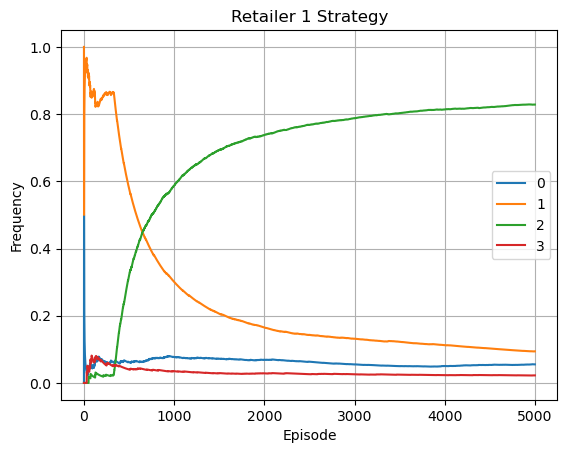

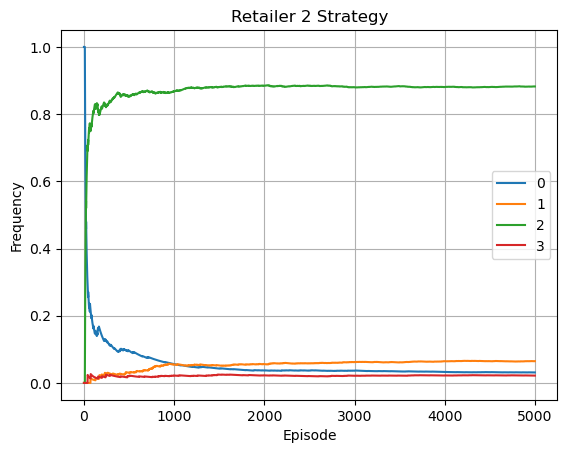

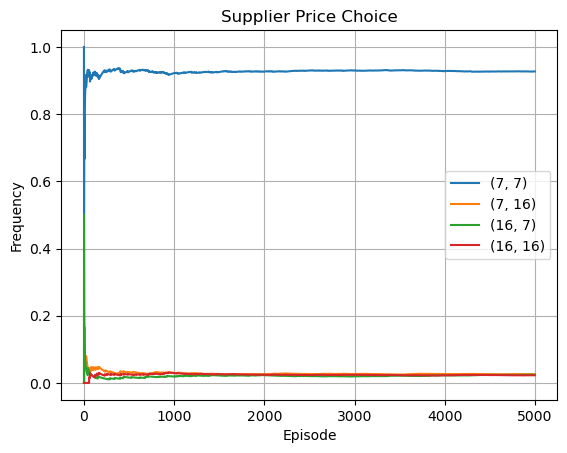

In [19]:
plot_strategies(r1_strategies, "Retailer 1 Strategy", retailer_actions)
plot_strategies(r2_strategies, "Retailer 2 Strategy", retailer_actions)
plot_strategies(s_choices, "Supplier Price Choice", supplier_actions)
